# Using interpretable axes in embedding space

This notebook is about using interpretable axes in embedding space along with minicons embeddings and clusters. 

## Getting the data in place

We again start with loading the data, and computing embeddings with minicons.

In [1]:
import torch
from minicons import cwe


# this is the BERT variant we're currently using
modelname = "bert-base-uncased"

# this is the object for computing embeddings
minicons_obj = cwe.CWE(modelname)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [2]:
import pandas as pd
import numpy as np

# the following code is to avoid this warning when running t-sne:
# "huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
# To disable this warning, you can either:
# - Avoid using `tokenizers` before the fork if possible
# 	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false) 
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
targetlemma = "draw"
inputdir = "data"
inputfilename = os.path.join(inputdir, targetlemma + ".csv")

df = pd.read_csv(inputfilename)
df.head()

,Unnamed: 0,tgt,sent,meta_file,meta_indices
0,0,drew,you must give them a sign to show them you are...,text_acad_1990.txt,"(21956428, 21956565)"
1,1,drew,<p> In the process of refining their new sense...,text_acad_1991.txt,"(6885982, 6886400)"
2,2,drew,"<p> At the end of World War II , when the Unit...",text_acad_1992.txt,"(4304831, 4305182)"
3,3,drew,"keeping his back to me , pushed him forward do...",text_acad_1994.txt,"(325341, 325726)"
4,4,draw,"For as noted in the beginning , great art tran...",text_acad_1994.txt,"(16779384, 16779549)"


We use minicons to compute embeddings for all the occurrences of "draw". The sentences are in column 'sent', the targets in column 'tgt'. We need to work in batches, so that minicons doesn't crash the kernel.

I'm using the last layer for now.

In [4]:
embs = [ ]
batchsize = 100

for startix in range(0, len(df), batchsize):

    # df is the pandas data frame containing the "draw" data.
    # to_dict("records") turns each row in the data frame into a dictionary 
    # where the column labels are keys and the column contents are values.
    # We extract data frames rows from start index to start index + batchsize,
    # and grab sentence and target word for each 
    sentences = [ (row["sent"], row["tgt"]) \
                  for row in df.iloc[startix:startix + batchsize].to_dict( "records") ]
    
    # print("Input to minicons: Here is one example sentence/target pair", sentences[0])

    currentbatch_embs = minicons_obj.extract_representation(sentences, layer = -1)

    # transform from torch tensors to numpy arrays
    currentbatch_embs = currentbatch_embs.detach().numpy()

    # and store the current batch
    embs.append(currentbatch_embs)

# combine all batches into a single matrix
embs = np.concatenate(embs, axis = 0)

Now we reduce the dimensionality of the embeddings to two using t-sne:

In [5]:
from sklearn.manifold import TSNE

twodim = TSNE(n_components = 2, random_state = 0).fit_transform(embs)

Here is a visualization, with text when you hover over a point. 

In [6]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.cm as cm

In [7]:
sentence_snippets = [ ]
windowsize = 5
    
for row in df.to_dict("records"):
    words = row["sent"].split()

    # sanity check
    if row["tgt"] not in words:
        # store the original sentence in its entirety
        sentence_snippets.append(" ".join(words))
        continue
    
    # determine the index of the target word
    targetindex = words.index(row["tgt"])
    
    # window of 5 words left and right of the target, 
    # but don't go below 0 or above the length of the sentence
    snippet_start = max(0, targetindex - windowsize)
    snippet_end = min(snippet_start + 2 * windowsize + 1, len(words))
    
    # make the snippet, as a string
    snippet = words[snippet_start : snippet_end]
    sentence_snippets.append(" ".join(snippet))


In [8]:
import mplcursors

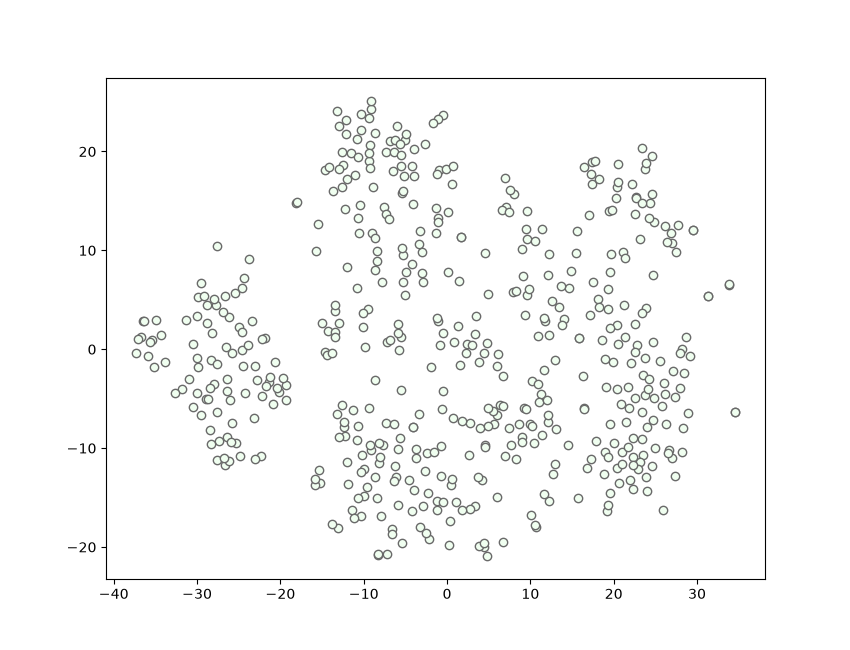

In [9]:
%matplotlib widget

# now we visualize again, with extra code to support the hovering
# set up the canvas
fig, ax =  plt.subplots()
fig.set_size_inches(8.5, 6.5)


# add a scatter plot of the two-D embeddings
scatter = ax.scatter(twodim[:,0], twodim[:,1], edgecolors="dimgray", c="honeydew")
cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(sentence_snippets[i])
    sel.annotation.set_fontsize(8)
    sel.annotation.set_fontfamily("DejaVu Sans")
    sel.annotation.set_color("black")
    
    box = sel.annotation.get_bbox_patch()
    box.set(fc="white", lw=0.8, alpha=0.9)  # fc=facecolor, ec=edgecolor
    box.set_boxstyle("round,pad=0.25")

    # sel.annotation.get_bbox_patch().set_visible(False)

plt.show()


## Clustering, and adding cluster colors to the plot

In this demo, I use k-means, a very simple clustering method, which however needs the number of clusters as an input. 



In [10]:
from sklearn.cluster import KMeans

numclusters = 7

# standard way to use machine learning from scikit learn:
# first make an object specific to the machine learning method
kmeans = KMeans(n_clusters=numclusters, random_state=0, n_init="auto")
# then fit it to the data
kmeans.fit(embs)

# done. now we can read off the results:
# the KMeans object now has a list of labels, one for
# each data point. The label says what cluster the data point goes to
clusterlabels = kmeans.labels_


In [11]:
from collections import defaultdict

# now we can pair the labels with the sentences to see which sentences got which label
# let's make a list of (sentence, target) pairs,
# this time for the whole dataset
sentences = [ (row["sent"], row["tgt"]) for row in df.to_dict( "records") ]
# pair up labels with sentences, 
# then turn this into a dictionay where the label is the key
# and the sentences are the values
cluster_sentences = defaultdict(list)
for clusterlabel, sent in zip(clusterlabels, sentences):
    cluster_sentences[ clusterlabel ].append(sent)

We now add cluster labels into the graph, using the parameter "c" that takes in a list of color indices, one for each datapoint to plot. 

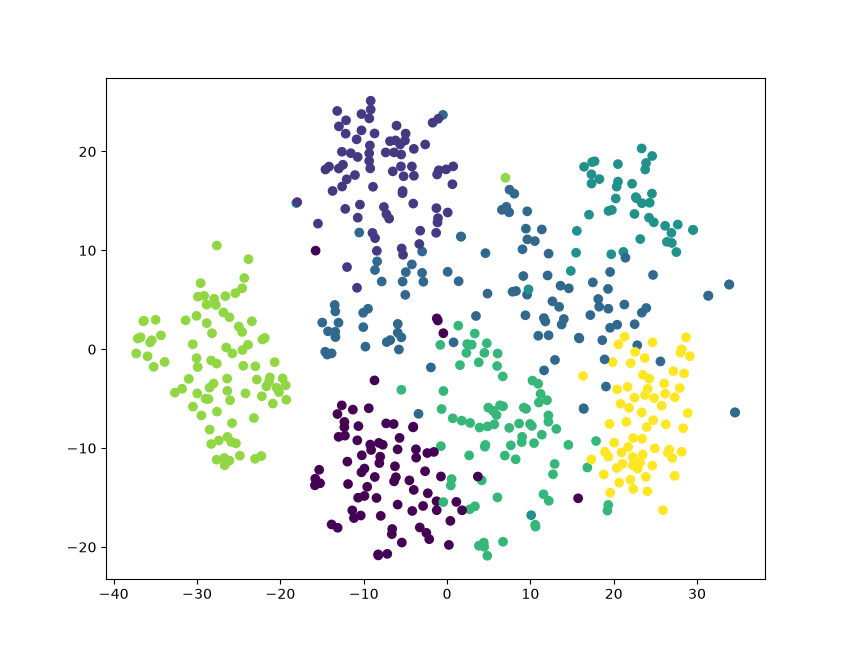

In [12]:
%matplotlib widget

# now we visualize again, with extra code to support the hovering
# set up the canvas
fig, ax =  plt.subplots()
fig.set_size_inches(8.5, 6.5)


# add a scatter plot of the two-D embeddings
# NEW STUFF HERE, parameters c and cmap
scatter = ax.scatter(twodim[:,0], twodim[:,1], c=clusterlabels, cmap = "viridis")
cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(sentence_snippets[i])
    sel.annotation.set_fontsize(8)
    sel.annotation.set_fontfamily("DejaVu Sans")
    sel.annotation.set_color("black")
    
    box = sel.annotation.get_bbox_patch()
    box.set(fc="white", lw=0.8, alpha=0.9)  # fc=facecolor, ec=edgecolor
    box.set_boxstyle("round,pad=0.25")

    # sel.annotation.get_bbox_patch().set_visible(False)

plt.show()


## Using interpretable axes

Embeddings are internal representations created by language models to best do the task of next-word prediction or masked-word prediction (and some other tasks). Recurring patterns that a language model "notices" as helpful for this task will be encoded in the embeddings. It turns out that some of these encoded patterns are encoded as directions, or axes, in the space: spanning from small object to large object, or from safe to dangerous, or from non-visual to visual. 

We can detect some of these axes by matching graded human ratings from psychology tasks to the best-fitting axes in embedding space, for example human ratings for the 64 high-level "mental domain" features by  Binder and colleagues: https://www.semanticscholar.org/paper/Toward-a-brain-based-componential-semantic-Binder-Conant/5d5a48b7c582d0d593e297a47c4ea0bccc0882c6  Some of these features are: Visual ("to what extent dooes this word describe something you can easily see?"), Biomotion ("to what extent does this word describe something that shows movement like that of a living thing?"), Social ("an activity or event that involves an  interaction between people"), and Pleasant ("someone or something that you find pleasant"). I have pre-computed axes for the Binder features (along with the VanArsdall animacy features, which we won't use here):


In [13]:
import zipfile
import json

# Reading in the data for the Binder axes
zip_infilename = "axes_last_bert-base-uncased_avg.json.zip"
infilename = "axes.json"

with zipfile.ZipFile(zip_infilename, "r", zipfile.ZIP_DEFLATED) as azip:
    with azip.open(infilename) as f:
        data = json.load(f)
        # for jsoning, embeddings are lists, so we can get the dimensionality that way
        # but now we turn them back to numpy
        axes = { }
        for axtype in data.keys():
            axes[axtype] = dict((k, np.array(e)) for k, e in data[axtype].items())

In [14]:
# "axes" is now a dictionary containing the Binder and VanArsdall features
axes.keys()

dict_keys(['Binder', 'VanArsdall'])

In [15]:
# and axes["Binder"] is a dictionary where the keys are all the Binder features
axes["Binder"].keys()

dict_keys(['Vision', 'Bright', 'Dark', 'Color', 'Pattern', 'Large', 'Small', 'Motion', 'Biomotion', 'Fast', 'Slow', 'Shape', 'Complexity', 'Face', 'Body', 'Touch', 'Temperature', 'Texture', 'Weight', 'Pain', 'Audition', 'Loud', 'Low', 'High', 'Sound', 'Music', 'Speech', 'Taste', 'Smell', 'Head', 'UpperLimb', 'LowerLimb', 'Practice', 'Landmark', 'Path', 'Scene', 'Near', 'Toward', 'Away', 'Number', 'Time', 'Duration', 'Long', 'Short', 'Caused', 'Consequential', 'Social', 'Human', 'Communication', 'Self', 'Cognition', 'Benefit', 'Harm', 'Pleasant', 'Unpleasant', 'Happy', 'Sad', 'Angry', 'Disgusted', 'Fearful', 'Surprised', 'Drive', 'Needs', 'Attention', 'Arousal'])

The way to use an axis is to *project* embeddings on it: to compute  the coordinates of the embedding on the axis. Here is the code for that:

In [16]:
import math

# vector scalar projection
def predict_scalarproj(veclist, dimension):
    dir_veclen = math.sqrt(np.dot(dimension, dimension))
    return [np.dot(v, dimension) / dir_veclen for v in veclist]


We compute projections for all the "draw" occurrences on all the Binder features, and add them to our dataframe.

In [17]:
# for each Binder axis:
for axislabel, axis in axes["Binder"].items():
    # compute projections of all embeddings on that axis
    projections = predict_scalarproj(embs, axis)
    # and add to the dataframe a column with the name of the axis
    # and the values that are the coordinates of all the embeddings on that axis
    df[ axislabel ] = projections

Here is what we have now:

In [18]:
df.head()

,Unnamed: 0,tgt,sent,meta_file,meta_indices,Vision,Bright,Dark,Color,Pattern,...,Happy,Sad,Angry,Disgusted,Fearful,Surprised,Drive,Needs,Attention,Arousal
0,0,drew,you must give them a sign to show them you are...,text_acad_1990.txt,"(21956428, 21956565)",0.128879,-0.451473,-0.213989,-0.297295,0.621274,...,-0.058507,-0.459936,-0.267937,-0.170848,-0.077287,-0.259475,0.255136,-0.138453,-0.291551,-0.031308
1,1,drew,<p> In the process of refining their new sense...,text_acad_1991.txt,"(6885982, 6886400)",-0.693181,0.553090,-1.312843,-1.051740,0.581105,...,0.586015,-0.565901,0.037000,-1.073885,-0.100321,0.403421,0.990574,-0.198037,0.887490,1.223275
2,2,drew,"<p> At the end of World War II , when the Unit...",text_acad_1992.txt,"(4304831, 4305182)",-0.122476,0.602857,-0.551661,-0.311717,0.921331,...,0.243937,0.000130,0.071175,-1.267736,0.357499,-0.082493,0.798799,-0.050703,0.223142,0.384901
3,3,drew,"keeping his back to me , pushed him forward do...",text_acad_1994.txt,"(325341, 325726)",-1.178873,-0.154177,-0.587600,-0.778579,-0.594744,...,-0.694007,0.269459,0.834147,0.127676,0.674172,0.405255,0.605546,-0.746535,0.990169,1.208478
4,4,draw,"For as noted in the beginning , great art tran...",text_acad_1994.txt,"(16779384, 16779549)",0.191455,0.645960,-0.023114,0.082691,0.173462,...,0.863447,0.381857,0.460849,-0.250276,0.855080,0.479408,1.387397,0.604409,1.117645,0.966670


In [19]:
#Let's look at some occurrences of "draw" that have
# the highest values on some feature.
# Here: Upper Limb (something involving arm, hand, or fingers)

df.sort_values(by = "UpperLimb", ascending = False).head().sent.to_list()


['" " Call it what you will , " said Gazian . " This is my desire . " Alaric drew another chord from the lute . " You overwhelm me , my lord .',
 '" Congratulations . " Nick had the grace to look embarrassed ; he drew her hand through his arm and said , " It \'s getting cold , we should turn back now .',
 'If you \'re smart you \'ll get out now before you start thinking like your knuckleheaded professors . " For emphasis he drew the Bowie knife out of its scabbard and drove it into the table where all us bloodless imitators were seated , mute before the rising legend .',
 "Both of us were , like idiots . I tried but could n't get a grip . Marion drew my fingers farther into her mouth . 1 was delirious .",
 'It should have been the last sight of my life . But just as Prescott drew his sword to skewer me , Slade handed the captain a jar of grey slime .']

In [20]:
# Another feature: Sad
df.sort_values(by = "Sad", ascending = False).head().sent.to_list()


["# Hester Young # The Gates of Evangeline # NOVEL # Secrets and lies , danger and romanceit all lies ahead for Charlotte , a New York journalist who 's mourning her dead son and having terrible dreams that draw her to the Louisiana bayou where another child has disappeared .",
 'I urge everyone to contact NYPD AND Bloomberg and demand the fucker be fired instead . He draws $154K annual salary , so his pension benefits , etc.',
 'Key battlegrounds : Native Americans and industry debate the social costs of protecting the dwindling runs of Pacific salmon that spawn in the Columbia River A federal proposal for 500 units of overnight housing in Mt . Hood National Forest draws opposition from outdoor advocates in Oregon . Ranchers are under fire from environmentalists who say livestock has stripped public land of vegetation and damaged sensitive ecosystems .',
 'Every time I tried I had to come back because the pain drew me . You know the story , the legend . " " Yes , " I said .',
 'Id . I

## Adding a feature into the graph as a color

We can add the coordinates (projections) of all the "draw" instances on some Binder axis into the graph. 


In [21]:
import scipy

# we rescale each property value by z-scoring for the analyses below
# Computing the z-score means normalizing the values with 
# mean at zero and standard deviation one
axis_cols = list(axes["Binder"].keys())

for axis in axis_cols:
    df[axis] = scipy.stats.zscore(df[axis])

In [22]:
# We use "UpperLimb" again.
# As we'll see, we get the highest values 
# for concrete uses of "draw"
property_level = df.UpperLimb 

# for each datapoint: we invert the number because we want the 
# darkest color to stand for the most intense value
property_level = [-ell for ell in property_level]

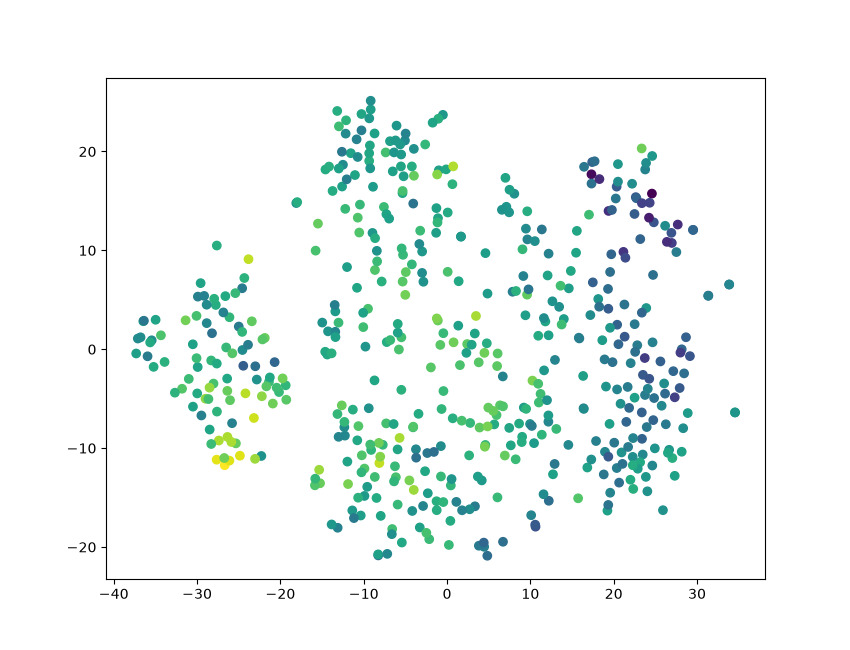

In [23]:
%matplotlib widget

# now we visualize again, with extra code to support the hovering
# set up the canvas
fig, ax =  plt.subplots()
fig.set_size_inches(8.5, 6.5)


# add a scatter plot of the two-D embeddings
# HERE we add c = propety_level to get the color of UpperLimb
scatter = ax.scatter(twodim[:,0], twodim[:,1], c=property_level, cmap = "viridis")
cursor = mplcursors.cursor(scatter, hover=True)

# this is again to support hovering
@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(sentence_snippets[i])
    sel.annotation.set_fontsize(8)
    sel.annotation.set_fontfamily("DejaVu Sans")
    sel.annotation.set_color("black")
    
    box = sel.annotation.get_bbox_patch()
    box.set(fc="white", lw=0.8, alpha=0.9)  # fc=facecolor, ec=edgecolor
    box.set_boxstyle("round,pad=0.25")

    # sel.annotation.get_bbox_patch().set_visible(False)

plt.show()


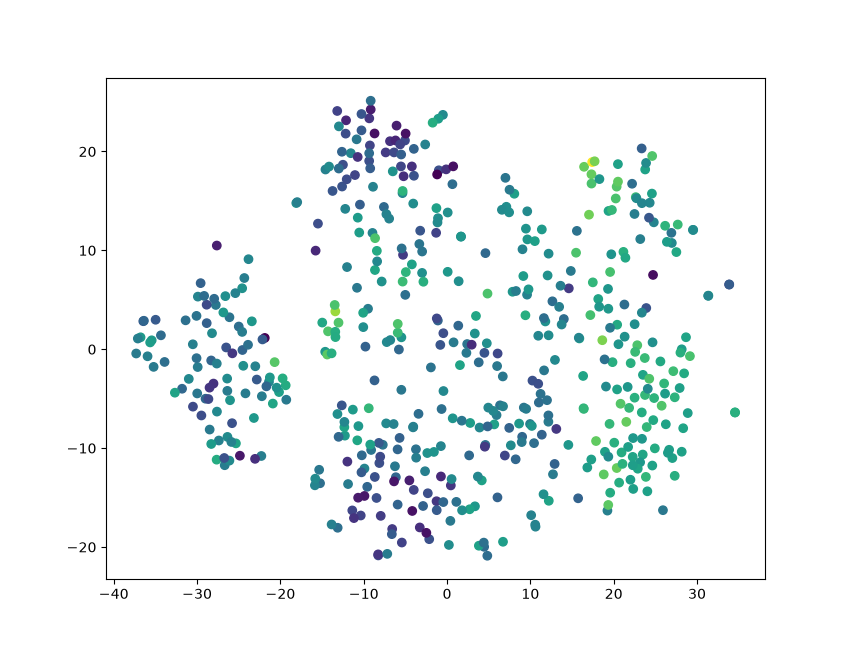

In [24]:
# Here is what happens when you instead use "Angry":
property_level = df.Angry
property_level = [-ell for ell in property_level]


# now we visualize again, with extra code to support the hovering
# set up the canvas
fig, ax =  plt.subplots()
fig.set_size_inches(8.5, 6.5)


# add a scatter plot of the two-D embeddings
# HERE we add c = propety_level to get the color of UpperLimb
scatter = ax.scatter(twodim[:,0], twodim[:,1], c=property_level, cmap = "viridis")
cursor = mplcursors.cursor(scatter, hover=True)

# this is again to support hovering
@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(sentence_snippets[i])
    sel.annotation.set_fontsize(8)
    sel.annotation.set_fontfamily("DejaVu Sans")
    sel.annotation.set_color("black")
    
    box = sel.annotation.get_bbox_patch()
    box.set(fc="white", lw=0.8, alpha=0.9)  # fc=facecolor, ec=edgecolor
    box.set_boxstyle("round,pad=0.25")

    # sel.annotation.get_bbox_patch().set_visible(False)

plt.show()


## Most distinctive features for each cluster



For each cluster, what are the Binder features that are highest for this cluster, compared to all others?

## Distinctive = highest value compared to all other clusters

Here is one way to do this: We compute the average Binder value for each feature and each cluster, then compute the difference between a target cluster's value and all others. The features that are highest in comparison to all others are the ones we call distinctive. 

We first compute average Binder values for each feature and each cluster. 

In [25]:
# compute cluster average feature values
# add in the cluster labels
df["Cluster"] = clusterlabels

# list of column names that are Binder features
axis_cols = list(axes["Binder"].keys())

# average feature values for each cluster
clusteravg_df = df.groupby("Cluster")[axis_cols].mean()
clusteravg_df = clusteravg_df.reset_index()
clusteravg_df.head(10)

,Cluster,Vision,Bright,Dark,Color,Pattern,Large,Small,Motion,Biomotion,...,Happy,Sad,Angry,Disgusted,Fearful,Surprised,Drive,Needs,Attention,Arousal
0,0,0.061340,-0.118641,0.537637,0.244239,-0.453885,0.548559,-0.611421,-0.264669,-0.644131,...,0.187460,0.520297,0.675239,0.537484,0.576590,0.869261,0.403929,-0.162082,0.812293,0.607099
1,1,-0.069134,0.337857,-0.650101,-0.485698,0.036674,0.743596,0.594919,0.340348,1.155086,...,-0.590074,0.189084,0.727594,0.615138,0.363992,0.955791,-0.294591,-1.083834,0.869428,1.039048
2,2,-0.261185,-0.197758,-0.198669,-0.217834,0.191562,0.005519,0.505091,0.227450,0.596759,...,0.203463,-0.194237,-0.441906,-0.438519,-0.517494,-0.445357,0.009260,0.003983,-0.422555,-0.139253
3,3,-0.228146,-0.436794,0.252209,-0.313930,0.137910,-0.433285,0.841339,0.951047,0.945740,...,0.247046,-0.573254,-0.771692,-0.288377,0.192641,-0.294684,-0.535538,0.028678,-0.739738,-0.483742
4,4,-0.027932,-0.017464,-0.183420,-0.184109,-0.093633,0.068801,-0.610627,-0.540075,-0.718499,...,-0.203051,0.255607,0.176924,0.072994,0.002100,-0.208488,0.490175,0.501256,-0.393634,-0.470687
5,5,-0.022435,-0.422977,-0.146748,0.016439,-0.401865,0.044403,-0.690916,-0.032467,-0.489613,...,-0.362248,0.133776,0.251749,0.340389,0.516252,0.139605,-0.352849,-0.001404,0.224048,0.047815
6,6,0.610179,0.924501,0.634634,0.973068,0.752618,-1.345514,0.347389,-0.377866,-0.594305,...,0.679686,-0.625362,-0.975092,-1.003532,-1.111240,-1.179796,0.103104,0.820648,-0.669951,-0.893116


Now we compute the features that are highest compared to all other clusters.

In [26]:
# Features that are highest compared to all other clusters
diffs = [ ]
for senselabel in clusteravg_df.Cluster:
    thisdiff = clusteravg_df[clusteravg_df.Cluster == senselabel][axis_cols] - clusteravg_df[clusteravg_df.Cluster != senselabel][axis_cols].mean()
    thisdiff = thisdiff.transpose()
    thisdiff.columns = [ senselabel ]
    diffs.append(thisdiff)

diffs_df = pd.concat(diffs, axis=1)
diffs_df.head()

,0,1,2,3,4,5,6
Vision,0.061115,-0.091104,-0.315164,-0.276618,-0.043035,-0.036621,0.701427
Bright,-0.149869,0.382713,-0.242172,-0.521047,-0.031828,-0.504927,1.067131
Dark,0.586319,-0.799375,-0.272704,0.253320,-0.254913,-0.212130,0.699483
Color,0.279583,-0.572010,-0.259502,-0.371614,-0.220156,0.013816,1.129883
Pattern,-0.557763,0.014556,0.195259,0.132665,-0.137469,-0.497073,0.849825


In [27]:
# For each cluster, show two sentences,
# and the features that are highest compared to all other clusters
for clusterlabel in clusteravg_df.Cluster:
    print("Cluster", clusterlabel)
    thiscluster_sents = df[df.Cluster == clusterlabel].sent.to_list()
    for i in range(2):
        print(thiscluster_sents[i])
    
    print()
    print( diffs_df[clusterlabel].sort_values(ascending = False).head())
    print()

Cluster 0
For as noted in the beginning , great art transcends its time . It transcends those who draw powers from it . It transcends those who exercise powers to affect it .
" <p> It is not just for their " polyphiloprogenitive " tendencies , however , that various creatures draw Beeton 's attention , but for their capacity to break down the very boundaries by which meaning and culture are secured , boundaries which Beeton has pledged herself and the Victorian household to defend .

Surprised    1.041416
Attention    1.001027
Angry        0.847310
Caused       0.762486
Arousal      0.757089
Name: 0, dtype: float64

Cluster 1
keeping his back to me , pushed him forward down the road about fifty yards -- he all the while endeavouring to turn round &; strike me , &; raging &; cursing , which drew out several neighbours ; at length , when I had got him to where he was Quarter 'd , which was very quickly done , we were met at the Gate by the Master of The Fox Inn ( who is the proprietor of

## Another variant: using regression. Here, distinctive = most predictive

Another way we can do this is to build a logistic regression model that tries to distinguish the members of a target cluster from all other clusters,  based only on Binder feature values. The Binder features that get the highest weights from that model are now the ones we call most distinctive. 



In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# tool for scaling data for the regression learner
scaler = StandardScaler()

# iterate over clusters
for clusterlabel in clusteravg_df.Cluster:
    # print cluster number, and two sentences
    print("Cluster", clusterlabel)
    thiscluster_sents = df[df.Cluster == clusterlabel].sent.to_list()
    for i in range(2):
        print(thiscluster_sents[i])
    
    print()

    # use regression modeling 
    # to predict membership in this cluster, 
    # based on Binder features. 
    #
    # Predictors: all the Binder features
    X = df[axis_cols]
    # scale the data so all the features
    # are of a similar magnitude
    X = scaler.fit_transform(X)
    # Dependent variable, what we want to predict:
    # that the cluster is our current target cluster
    # (with label clusterlabel)
    y = (df.Cluster == clusterlabel).astype(int)
    # Build a logistic regression model, 
    # without regularization (that's the C = ...)
    lrmodel = LogisticRegression(max_iter=1000, C=np.inf)
    lrmodel.fit(X, y)

    # show the axes with the highest coefficient
    # (the ones most predictive of this cluster)
    axis_coef = pd.DataFrame({"axis":axis_cols, "coef":lrmodel.coef_[0]})
    print(axis_coef.sort_values(by = "coef", ascending = False).head())



Cluster 0
For as noted in the beginning , great art transcends its time . It transcends those who draw powers from it . It transcends those who exercise powers to affect it .
" <p> It is not just for their " polyphiloprogenitive " tendencies , however , that various creatures draw Beeton 's attention , but for their capacity to break down the very boundaries by which meaning and culture are secured , boundaries which Beeton has pledged herself and the Victorian household to defend .

        axis       coef
18    Weight  37.546867
57     Angry  30.843504
53  Pleasant  23.741745
7     Motion  20.840898
29      Head  20.578515
Cluster 1
keeping his back to me , pushed him forward down the road about fifty yards -- he all the while endeavouring to turn round &; strike me , &; raging &; cursing , which drew out several neighbours ; at length , when I had got him to where he was Quarter 'd , which was very quickly done , we were met at the Gate by the Master of The Fox Inn ( who is the prop